# $H_2O$/6-31G

Two-body negativities of $H_2O$ in the 6-31G basis compared with the
STO-3G results (manuscript Fig. 10), for the ground state and the thermal
state at $\beta = 1000\,E_h^{-1}$.

Library code: `h2o_631g.py` (iterative-FCI engine, scan driver, figure);
`h2o_core.py`/`h2o_rdm.py` supply the exact STO-3G curves.

## Model and conventions

* Same molecule and geometry scan as the STO-3G notebook: HOH angle
  104.5°, both O–H bonds stretched together, $R \in [0.4, 4.0]$ Å.
* 6-31G: 13 spatial orbitals ($d=26$ spin orbitals); the fixed-$M_S=0$
  sector holds $\binom{13}{5}^2 = 1{,}656{,}369$ Slater determinants, far
  beyond the dense-spectrum approach, so the engine uses PySCF iterative
  FCI (Davidson) and `fci.direct_spin1.make_rdm12s` for the spin-resolved
  two-body blocks.
* Ground state: `direct_spin0` with a spin-penalty ladder selecting $S=0$,
  plus a variational guard. The final ground state is the lowest
  spin-pure ($\langle S^2\rangle < 10^{-5}$) state among the penalty solve
  and the thermal roots.
* Thermal state: lowest 16 $M_S=0$ roots of any $S$, Boltzmann weights
  closed over degenerate clusters.
* Both negativities are stored and plotted on the equation scale. The STO-3G 
  ground-state $\mathcal{N}^{(2)}_{\uparrow\downarrow}$ reaches $5/6$ at 
  dissociation.

In [13]:
import os
for var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS",
            "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(var, "1")

import json
import time

import matplotlib.pyplot as plt

import h2o_core as core
import h2o_631g as g631

print(f"basis={g631.BASIS_631G}  theta={g631.THETA_DEG} deg  "
      f"beta={g631.BETA_HARTREE_INVERSE} 1/E_h  "
      f"grid={g631.R_GRID_631G[0]}..{g631.R_GRID_631G[-1]} A "
      f"({len(g631.R_GRID_631G)} points)")

basis=6-31g  theta=104.5 deg  beta=1000.0 1/E_h  grid=0.4..4.0 A (37 points)


## STO-3G reference scan - exact dense pipeline

The STO-3G curves of Fig. 10 come from the same dense-spectrum pipeline
that produces Figs. 2–8.

In [14]:
t0 = time.time()
SESSION = core.build_session()
POINTS = core.run_scan(session=SESSION)
ARRAYS = core.scan_arrays(POINTS)
print(f"{len(POINTS)} geometries in {time.time() - t0:.0f} s")

R scan: 100%|███████████████████████████████████| 73/73 [05:11<00:00,  4.27s/it]

73 geometries in 313 s


## 6-31G scan (cached)

The 6-31G scan is precomputed with

```
python h2o_631g.py --scan --threads 4 --workers 4
```

(minutes per geometry, hours in total on a few cores). The cell
below loads `data/h2o_631g_scan.json`

In [20]:
RECORDS = json.load(open(g631.DATA_DIR / "h2o_631g_scan.json"))
ok = [rec for rec in RECORDS if "error" not in rec]
assert len(ok) == len(RECORDS), f"{len(RECORDS) - len(ok)} error records"
assert all(rec["thermal_meta"]["all_converged"] for rec in ok)
worst_last_weight = max(rec["thermal_meta"]["last_root_weight"]
                        for rec in ok)
assert worst_last_weight < 1.0e-10, worst_last_weight
assert all(rec["gs_energy"] <= rec["thermal_meta"]["energies"][0] + 1e-7
           for rec in ok)
guard = [(rec["r_angstrom"], rec["gs_guard"]["source"]) for rec in ok
         if rec["gs_guard"]["source"] != "fix_spin"]
band = [(rec["r_angstrom"], rec["thermal_meta"]["band_size_1mEh"])
        for rec in ok if rec["r_angstrom"] >= g631.BAND_R_MIN]
print(f"{len(ok)} points | max last-root weight {worst_last_weight:.1e}")

37 points | max last-root weight 8.5e-25


### Figure 10 - two-body negativities across basis sets

Color encodes the observable (green
$\mathcal{N}^{(2)}_{\uparrow\downarrow}$, red
$\mathcal{N}^{(2)}_{\uparrow\uparrow}$), linestyle encodes the basis
(solid 6-31G, dash-dot STO-3G).

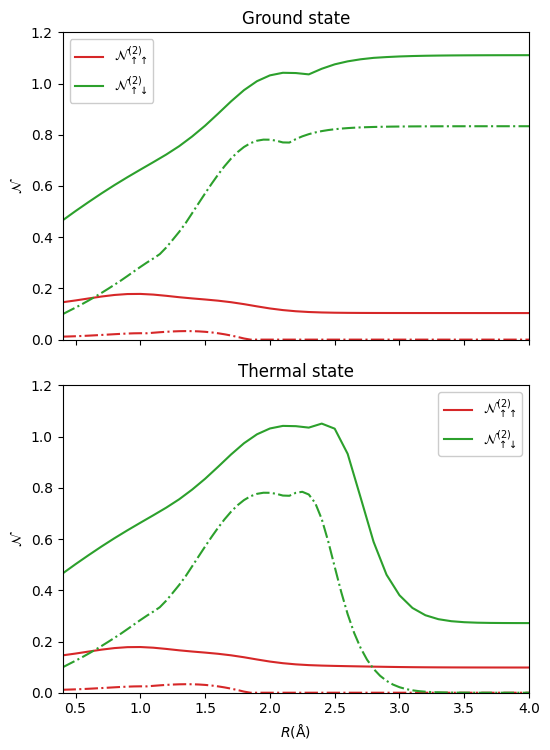

In [19]:
DATA10 = g631.compute_figure10_data(ARRAYS, RECORDS)
fig = g631.plot_figure10(DATA10)
plt.show()